# Student Academic Insights Dashboard

In [3]:
# ==========================================================
# WEEK 7 CAPSTONE PROJECT
# Student Academic Insights Dashboard
# ==========================================================

# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)













In [4]:
# ==========================================================
# 2. LOAD DATASET
# ==========================================================

df = pd.read_csv("Student_data.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


Dataset Shape:
(5000, 10)

First 5 Rows:
  Student_ID  Gender  Age        Major  Attendance_Pct  Study_Hours_Per_Day  \
0    ID00001    Male   20  Engineering            83.9                  4.4   
1    ID00002  Female   24     Business            80.7                  4.0   
2    ID00003  Female   20  Mathematics            91.5                  3.9   
3    ID00004  Female   23  Engineering            73.9                  8.8   
4    ID00005    Male   21    Economics            79.8                  2.2   

   Previous_CGPA  Sleep_Hours  Social_Hours_Week  Final_CGPA  
0           2.65          9.1                  8        2.78  
1           3.58          4.0                  4        3.76  
2           3.29          6.7                  4        3.75  
3           3.48          4.0                  6        3.69  
4           2.66          8.7                  6        2.34  


In [5]:
# ==========================================================
# 3. DATA CLEANING
# ==========================================================

# Remove duplicates
df.drop_duplicates(inplace=True)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Dataset Information
print("\nDataset Information:")
print(df.info())



Missing Values:
Student_ID             0
Gender                 0
Age                    0
Major                  0
Attendance_Pct         0
Study_Hours_Per_Day    0
Previous_CGPA          0
Sleep_Hours            0
Social_Hours_Week      0
Final_CGPA             0
dtype: int64

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           5000 non-null   str    
 1   Gender               5000 non-null   str    
 2   Age                  5000 non-null   int64  
 3   Major                5000 non-null   str    
 4   Attendance_Pct       5000 non-null   float64
 5   Study_Hours_Per_Day  5000 non-null   float64
 6   Previous_CGPA        5000 non-null   float64
 7   Sleep_Hours          5000 non-null   float64
 8   Social_Hours_Week    5000 non-null   int64  
 9   Final_CGPA           5000 non-null   float64
dt

In [6]:
# ==========================================================
# 4. CREATE GRADE CATEGORY
# ==========================================================

def grade_category(cgpa):
    if cgpa >= 3.5:
        return "Excellent"
    elif cgpa >= 3.0:
        return "Good"
    elif cgpa >= 2.5:
        return "Average"
    else:
        return "Poor"

df["Grade_Category"] = df["Final_CGPA"].apply(grade_category)

print("\nGrade Category Distribution:")
print(df["Grade_Category"].value_counts())


Grade Category Distribution:
Grade_Category
Excellent    1806
Good         1734
Average      1076
Poor          384
Name: count, dtype: int64


In [7]:
# ==========================================================
# 5. SAVE CLEAN DATASET
# ==========================================================

df.to_csv("Clean_Student_Data.csv", index=False)

print("\nClean dataset saved successfully.")


Clean dataset saved successfully.


In [8]:
# ==========================================================
# 6. STATISTICAL ANALYSIS
# ==========================================================

print("\nDescriptive Statistics:")
print(df.describe())

print("\nAverage Final CGPA:")
print(round(df["Final_CGPA"].mean(), 2))

print("\nAverage Attendance:")
print(round(df["Attendance_Pct"].mean(), 2))

print("\nAverage Study Hours:")
print(round(df["Study_Hours_Per_Day"].mean(), 2))

print("\nAverage Sleep Hours:")
print(round(df["Sleep_Hours"].mean(), 2))



Descriptive Statistics:
               Age  Attendance_Pct  Study_Hours_Per_Day  Previous_CGPA  \
count  5000.000000     5000.000000          5000.000000    5000.000000   
mean     20.948600       83.795740             4.517840       3.093824   
std       2.017417       12.867904             2.568104       0.476754   
min      18.000000       26.200000             0.100000       1.350000   
25%      19.000000       75.100000             2.600000       2.760000   
50%      21.000000       85.050000             4.000000       3.100000   
75%      23.000000       94.800000             6.000000       3.430000   
max      24.000000      100.000000            14.000000       4.000000   

       Sleep_Hours  Social_Hours_Week   Final_CGPA  
count  5000.000000        5000.000000  5000.000000  
mean      7.012060           8.006400     3.272224  
std       1.424377           2.797771     0.507954  
min       4.000000           0.000000     1.160000  
25%       6.000000           6.000000     2

In [9]:
# ==========================================================
# 7. CORRELATION ANALYSIS
# ==========================================================

numeric_columns = [
    'Age',
    'Attendance_Pct',
    'Study_Hours_Per_Day',
    'Previous_CGPA',
    'Sleep_Hours',
    'Social_Hours_Week',
    'Final_CGPA'
]

correlation = df[numeric_columns].corr()

print("\nCorrelation Matrix:")
print(correlation)



Correlation Matrix:
                          Age  Attendance_Pct  Study_Hours_Per_Day  \
Age                  1.000000        0.023755             0.010266   
Attendance_Pct       0.023755        1.000000             0.022700   
Study_Hours_Per_Day  0.010266        0.022700             1.000000   
Previous_CGPA       -0.024369        0.024346            -0.003302   
Sleep_Hours          0.003738       -0.017246            -0.021983   
Social_Hours_Week    0.003921        0.011411             0.002351   
Final_CGPA          -0.012245        0.302840             0.230898   

                     Previous_CGPA  Sleep_Hours  Social_Hours_Week  Final_CGPA  
Age                      -0.024369     0.003738           0.003921   -0.012245  
Attendance_Pct            0.024346    -0.017246           0.011411    0.302840  
Study_Hours_Per_Day      -0.003302    -0.021983           0.002351    0.230898  
Previous_CGPA             1.000000     0.012845           0.012686    0.878879  
Sleep_Hours  

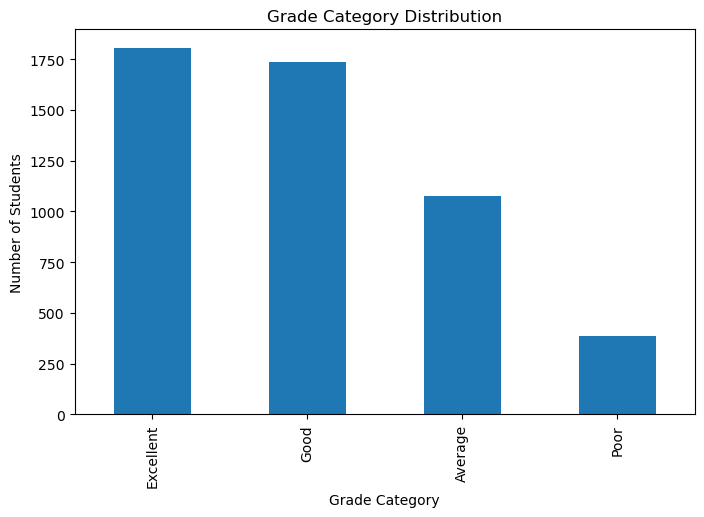

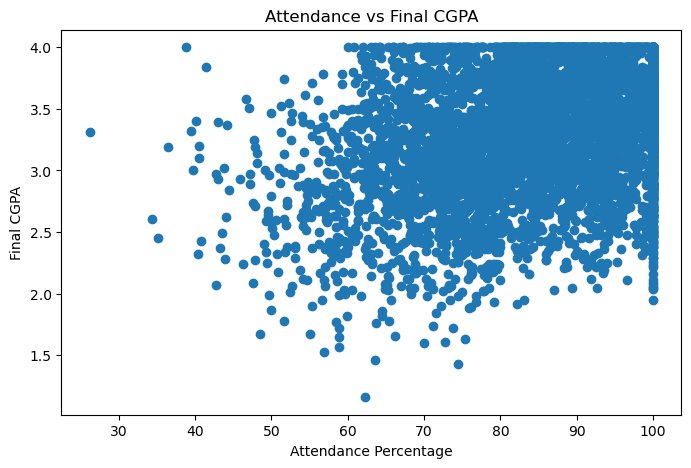

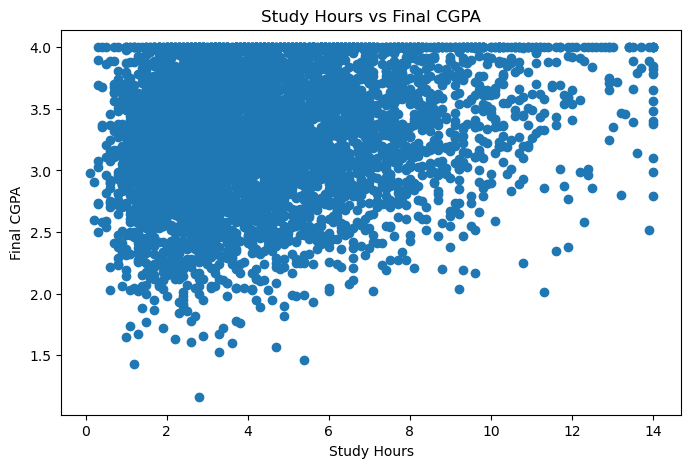

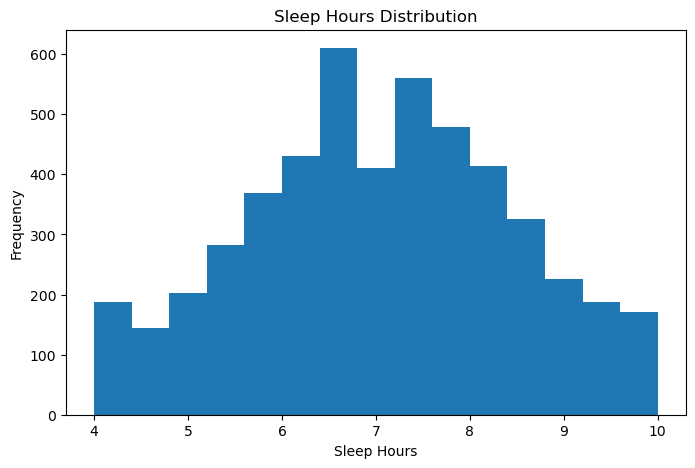

<Figure size 1000x600 with 0 Axes>

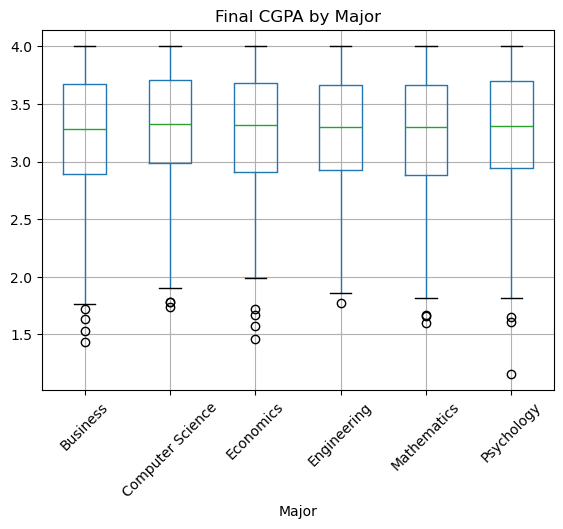

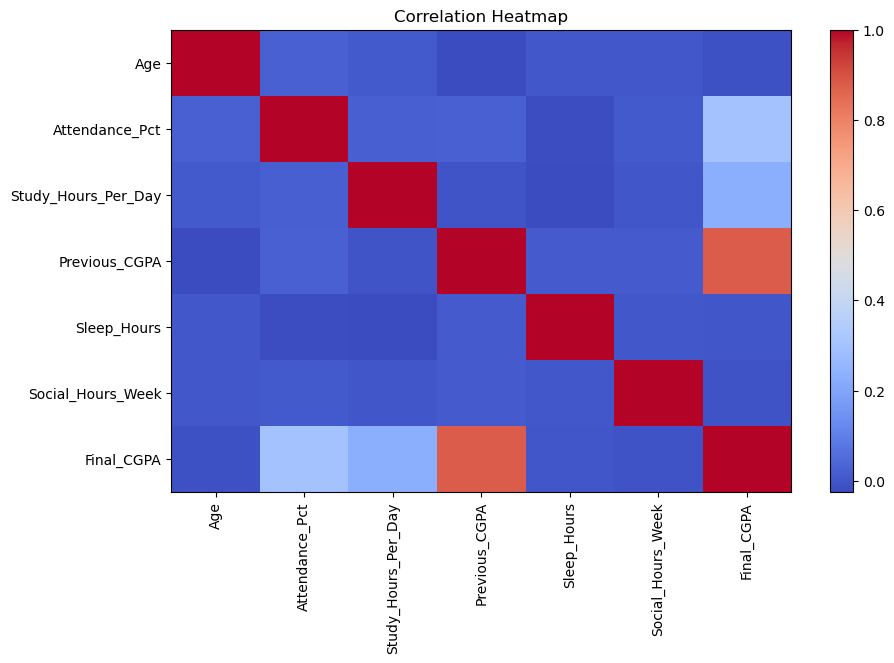

In [10]:
# ==========================================================
# 8. VISUALIZATIONS (MATPLOTLIB)
# ==========================================================

# Grade Distribution

plt.figure(figsize=(8,5))

df["Grade_Category"].value_counts().plot(
    kind='bar'
)

plt.title("Grade Category Distribution")
plt.xlabel("Grade Category")
plt.ylabel("Number of Students")

plt.savefig("grade_distribution.png")
plt.show()

# ----------------------------------------------------------

# Attendance vs Final CGPA

plt.figure(figsize=(8,5))

plt.scatter(
    df["Attendance_Pct"],
    df["Final_CGPA"]
)

plt.title("Attendance vs Final CGPA")
plt.xlabel("Attendance Percentage")
plt.ylabel("Final CGPA")

plt.savefig("attendance_vs_cgpa.png")
plt.show()

# ----------------------------------------------------------

# Study Hours vs Final CGPA

plt.figure(figsize=(8,5))

plt.scatter(
    df["Study_Hours_Per_Day"],
    df["Final_CGPA"]
)

plt.title("Study Hours vs Final CGPA")
plt.xlabel("Study Hours")
plt.ylabel("Final CGPA")

plt.savefig("study_vs_cgpa.png")
plt.show()

# ----------------------------------------------------------

# Sleep Hours Distribution

plt.figure(figsize=(8,5))

plt.hist(
    df["Sleep_Hours"],
    bins=15
)

plt.title("Sleep Hours Distribution")
plt.xlabel("Sleep Hours")
plt.ylabel("Frequency")

plt.savefig("sleep_distribution.png")
plt.show()

# ----------------------------------------------------------

# Final CGPA by Major

plt.figure(figsize=(10,6))

df.boxplot(
    column="Final_CGPA",
    by="Major",
    rot=45
)

plt.title("Final CGPA by Major")
plt.suptitle("")

plt.savefig("cgpa_by_major.png")
plt.show()

# ----------------------------------------------------------

# Correlation Heatmap

plt.figure(figsize=(10,6))

plt.imshow(
    correlation,
    cmap='coolwarm',
    aspect='auto'
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")
plt.show()


In [11]:
# ==========================================================
# 9. MACHINE LEARNING MODEL
# ==========================================================

X = df.drop(
    columns=[
        "Student_ID",
        "Final_CGPA",
        "Grade_Category"
    ]
)

y = df["Grade_Category"]


In [12]:

# ==========================================================
# 10. TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [13]:
# ==========================================================
# 11. PREPROCESSING
# ==========================================================

categorical_features = [
    'Gender',
    'Major'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)



In [14]:
# ==========================================================
# 12. RANDOM FOREST MODEL
# ==========================================================

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        (
            'classifier',
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)






In [15]:
# ==========================================================
# 13. TRAIN MODEL
# ==========================================================

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [16]:
# ==========================================================
# 14. PREDICTIONS
# ==========================================================

y_pred = model.predict(X_test)

In [17]:
# ==========================================================
# 15. MODEL EVALUATION
# ==========================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:")
print(round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)




Accuracy:
78.5 %

Classification Report:
              precision    recall  f1-score   support

     Average       0.70      0.70      0.70       215
   Excellent       0.88      0.88      0.88       361
        Good       0.72      0.78      0.75       347
        Poor       0.89      0.62      0.73        77

    accuracy                           0.79      1000
   macro avg       0.80      0.74      0.77      1000
weighted avg       0.79      0.79      0.78      1000




Confusion Matrix:
[[150   0  59   6]
 [  0 316  45   0]
 [ 34  42 271   0]
 [ 29   0   0  48]]


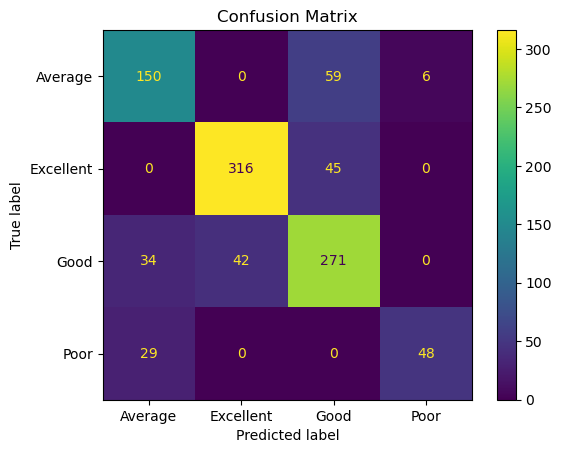

In [18]:
# ==========================================================
# 16. CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()




Top 10 Important Features:
                           Feature  Importance
11        remainder__Previous_CGPA    0.489186
9        remainder__Attendance_Pct    0.144313
10  remainder__Study_Hours_Per_Day    0.114378
12          remainder__Sleep_Hours    0.080445
13    remainder__Social_Hours_Week    0.059868
8                   remainder__Age    0.045802
2              cat__Major_Business    0.008457
1                 cat__Gender_Male    0.008406
7            cat__Major_Psychology    0.008404
6           cat__Major_Mathematics    0.008397


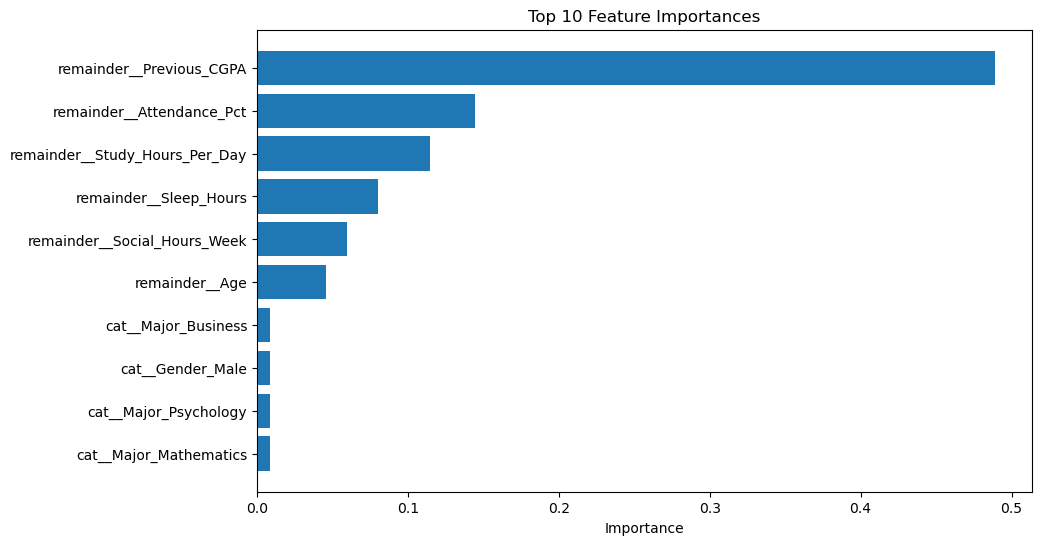

In [19]:
# ==========================================================
# 17. FEATURE IMPORTANCE
# ==========================================================

rf_model = model.named_steps['classifier']

feature_names = (
    model.named_steps['preprocessor']
    .get_feature_names_out()
)

importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 10 Important Features:")
print(
    importance_df.head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    importance_df.head(10)['Feature'],
    importance_df.head(10)['Importance']
)

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances")

plt.xlabel("Importance")

plt.savefig("feature_importance.png")

plt.show()



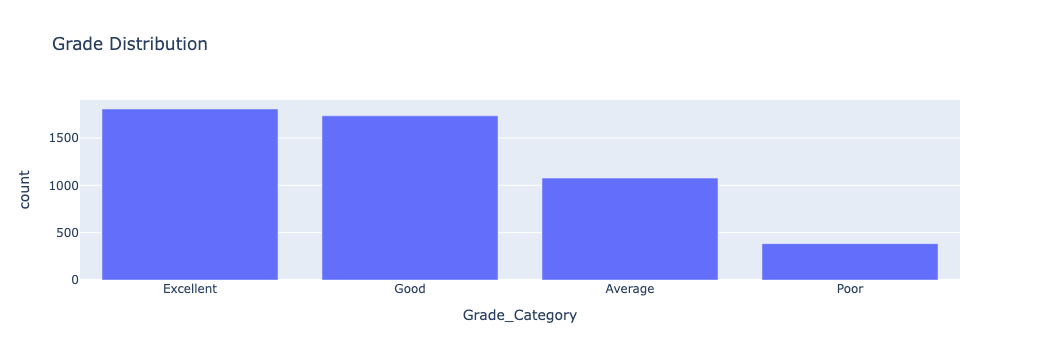

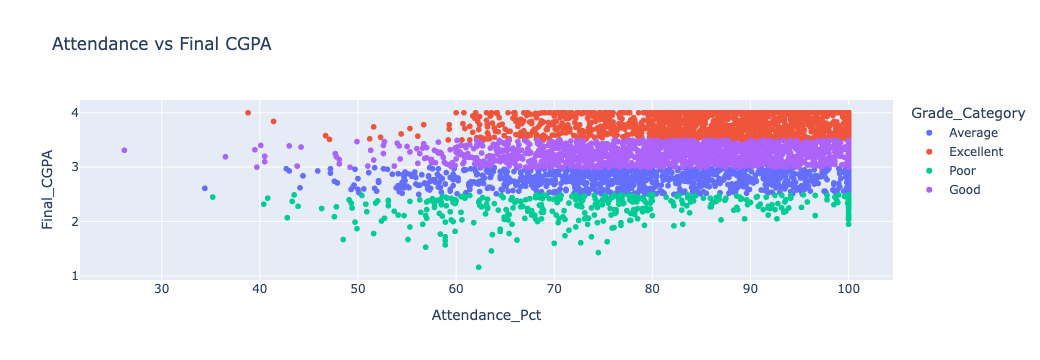

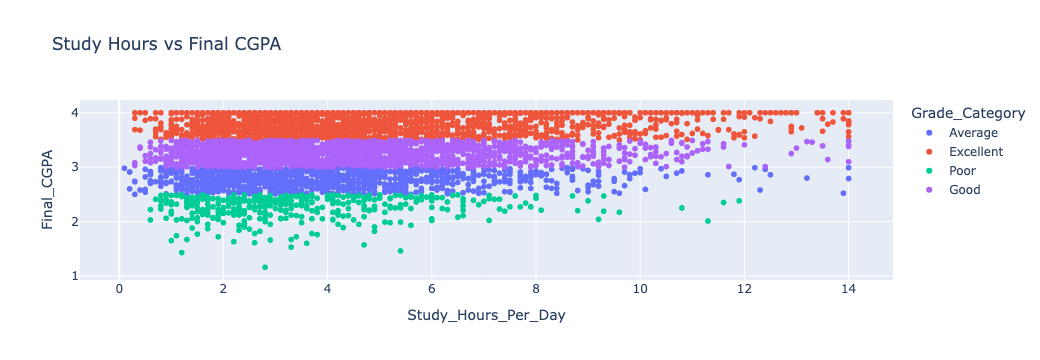

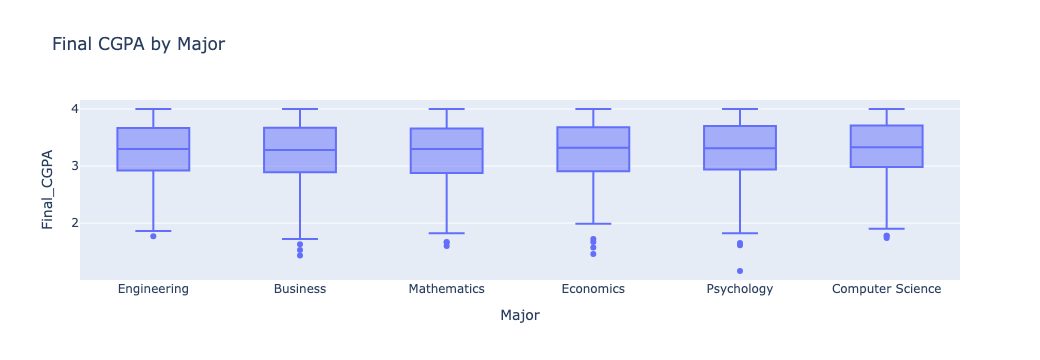

In [20]:
# ==========================================================
# 18. INTERACTIVE DASHBOARD (PLOTLY)
# ==========================================================

# Grade Distribution Dashboard

fig1 = px.bar(
    df["Grade_Category"].value_counts().reset_index(),
    x='Grade_Category',
    y='count',
    title='Grade Distribution'
)

fig1.show()

# ----------------------------------------------------------

# Attendance vs CGPA Dashboard

fig2 = px.scatter(
    df,
    x='Attendance_Pct',
    y='Final_CGPA',
    color='Grade_Category',
    title='Attendance vs Final CGPA'
)

fig2.show()

# ----------------------------------------------------------

# Study Hours vs CGPA Dashboard

fig3 = px.scatter(
    df,
    x='Study_Hours_Per_Day',
    y='Final_CGPA',
    color='Grade_Category',
    title='Study Hours vs Final CGPA'
)

fig3.show()

# ----------------------------------------------------------

# Major-wise CGPA Dashboard

fig4 = px.box(
    df,
    x='Major',
    y='Final_CGPA',
    title='Final CGPA by Major'
)

fig4.show()



In [21]:
# ==========================================================
# 19. SAVE MODEL EVALUATION
# ==========================================================

with open(
    "Model_Evaluation.txt",
    "w"
) as file:

    file.write(
        f"Accuracy: {accuracy:.4f}\n\n"
    )

    file.write(
        classification_report(
            y_test,
            y_pred
        )
    )

print("\nModel Evaluation saved successfully.")




Model Evaluation saved successfully.


In [22]:
# ==========================================================
# 20. PROJECT COMPLETED
# ==========================================================

print("\n===================================")
print("PROJECT COMPLETED SUCCESSFULLY")
print("===================================")

print("\nFiles Generated:")

print("1. Clean_Student_Data.csv")
print("2. grade_distribution.png")
print("3. attendance_vs_cgpa.png")
print("4. study_vs_cgpa.png")
print("5. sleep_distribution.png")
print("6. cgpa_by_major.png")
print("7. correlation_heatmap.png")
print("8. confusion_matrix.png")
print("9. feature_importance.png")
print("10. Model_Evaluation.txt")
print("\nReady for Power BI Dashboard Creation.")


PROJECT COMPLETED SUCCESSFULLY

Files Generated:
1. Clean_Student_Data.csv
2. grade_distribution.png
3. attendance_vs_cgpa.png
4. study_vs_cgpa.png
5. sleep_distribution.png
6. cgpa_by_major.png
7. correlation_heatmap.png
8. confusion_matrix.png
9. feature_importance.png
10. Model_Evaluation.txt

Ready for Power BI Dashboard Creation.
